<a href="https://colab.research.google.com/github/arhamk15/physics-projects/blob/main/Nuclear%20Fission%20Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
L = 0.1 #m
a = 1.7e-2 #cm to m - mean free path neutron hitting another nucleus and bouncing off
b = 21e-2 # cm to m - mean free path between neutron hitting a nucleus and causing fission
R = np.sqrt(2*a*b) # rms distance that a neutron diffuses away from its starting point before causing a collision
n_fissions = 1000 # no. of intial fission runs

counter = 0

for fission in range(n_fissions):

  initial_position = L*np.random.random()

  for neutron in range(0,2):
    neutron_direction = np.random.random()
    if neutron_direction < 0.5:
      secondary_position = initial_position - R
    else:
      secondary_position = initial_position + R

    if 0 <= secondary_position <= L:
      counter += 1


print(counter/n_fissions)




0.328


In [ ]:
from math import cos, log, pi, sqrt
from numpy import random

def neutrons():
    """Number of secondary neutrons produced in each fission.

    Returns an integer number of neutrons, with average 2.5."""
    i=int(random.normal()+3)
    if (i<0): return 0
    else: return i

def diffusion():
    """Distance diffused by a neutron before causing fission.

    Returns a random number with probability density p(s) =
    s^2 exp(-3s^2/R^2). This distribution has a mean of 1, so
    multiply by R to get the physical distance."""
    a=cos(2.0*pi*random.random())
    return sqrt(-0.667*(log(random.random())+log(random.random())*a*a))*R


In [ ]:
samples = 75
Ls = np.linspace(0.1, 1, samples) #m
#print(Ls)
a = 1.7e-2 #cm to m - mean free path neutron hitting another nucleus and bouncing off
b = 21e-2 # cm to m - mean free path between neutron hitting a nucleus and causing fission
R = np.sqrt(2*a*b) # rms distance that a neutron diffuses away from its starting point before causing a collision
n_fissions = 100 # no. of intial fission runs

counts_for_L = []
results = []
#print(counts_per_L)

for L in Ls:
  total_counts_for_L= 0

  for fission_num in range(n_fissions):
    initial_position = L*np.random.random()
    counter = 0 # unique  counter for each set of n_fissions at each length

    # neutrons() gives the number of secondary neutrns
    for neutron_num in range(neutrons()):
      direction = np.random.random() # gives the random probability in a probability space [0,1] of a secondary neutron

      if direction < 0.5:
        secondary_position = initial_position - R

      else:
        secondary_position = initial_position + R

      if 0 <= secondary_position <= L:
        counter += 1

    total_counts_for_L += counter # allows us to have one value of summation of all runs rather than n_samples of columns in the array of 'results' - goves total number of fissions


  avg_fissions = total_counts_for_L/n_fissions  # this gives the prob of fission happening

  results.append([L,avg_fissions]) # be careful of indentations used here.


results = np.array(results)


print(results)

optimal = np.argmax(results, axis = 0)


print(optimal[1])
print('The optimal value of fissions is at L = ', Ls[optimal[1]])

 # 0.17297297 optimal value of length for stable chain fission.


'''
counts_per_L = np.array(counts_per_L)

counts_per_L = np.reshape(counts_per_L, (-1,n_fissions)) # for each value of L, we n_fissions simulated

counts_sum = np.sum(counts_per_L, axis = 1 )
counts_sum = np.concatenate([Ls.reshape(-1, 1), counts_sum.reshape(-1, 1)], axis = 1)

print(counts_sum)
#print(Ls)

optimal = np.argmax(counts_sum, axis = 0)
print(optimal)
print('The optimal value of fissions is at L = ', Ls[optimal])

#print(len(counts_per_L[0]))

#The optimal value of arounf L = 0.81 or 0.95 '''

[[0.1        0.47      ]
 [0.11216216 0.62      ]
 [0.12432432 0.93      ]
 [0.13648649 0.74      ]
 [0.14864865 1.24      ]
 [0.16081081 1.22      ]
 [0.17297297 1.27      ]
 [0.18513514 1.17      ]
 [0.1972973  1.48      ]
 [0.20945946 1.38      ]
 [0.22162162 1.7       ]
 [0.23378378 1.43      ]
 [0.24594595 1.72      ]
 [0.25810811 1.73      ]
 [0.27027027 1.75      ]
 [0.28243243 1.67      ]
 [0.29459459 1.63      ]
 [0.30675676 1.7       ]
 [0.31891892 1.74      ]
 [0.33108108 1.96      ]
 [0.34324324 1.88      ]
 [0.35540541 2.05      ]
 [0.36756757 1.8       ]
 [0.37972973 2.11      ]
 [0.39189189 1.96      ]
 [0.40405405 1.95      ]
 [0.41621622 1.87      ]
 [0.42837838 1.99      ]
 [0.44054054 1.91      ]
 [0.4527027  1.91      ]
 [0.46486486 2.08      ]
 [0.47702703 1.98      ]
 [0.48918919 2.14      ]
 [0.50135135 2.22      ]
 [0.51351351 1.94      ]
 [0.52567568 2.11      ]
 [0.53783784 2.07      ]
 [0.55       2.09      ]
 [0.56216216 2.07      ]
 [0.57432432 2.14      ]


"\ncounts_per_L = np.array(counts_per_L)\n\ncounts_per_L = np.reshape(counts_per_L, (-1,n_fissions)) # for each value of L, we n_fissions simulated\n\ncounts_sum = np.sum(counts_per_L, axis = 1 )\ncounts_sum = np.concatenate([Ls.reshape(-1, 1), counts_sum.reshape(-1, 1)], axis = 1)\n\nprint(counts_sum)\n#print(Ls)\n\noptimal = np.argmax(counts_sum, axis = 0)\nprint(optimal)\nprint('The optimal value of fissions is at L = ', Ls[optimal])\n\n#print(len(counts_per_L[0]))\n\n#The optimal value of arounf L = 0.81 or 0.95 "

In [ ]:
def phi_rand():
  return 2*np.pi*np.random.random()

def theta_rand():
  return np.arccos(2*np.random.random()-1)

def x_position(x, prob,s,theta,phi):
  ''' inital fission position => init_fiss_pos '''
  #s = diffusion()

  if prob > 0.5:
    return  x + s*(np.sin(theta) * np.cos( phi ))
  else:
    return  x - s*( np.sin( theta) * np.cos( phi ))


def y_position(y, prob,s,theta,phi):
  #s = diffusion()

  if prob > 0.5:
    return  y + s*( np.sin( theta) * np.sin( phi) )

  else:
    return  y - s*( np.sin( theta) * np.sin( phi ) )

def z_position(z, prob,s,theta,phi):
  #s = diffusion()
  if prob > 0.5:
    return  z + s*np.cos( theta)
  else:
    return  z - s*np.cos( theta )
def fission(n_fissions):
  counts_per_L = []
  joint_list = []

  for L in Ls:

    counts_per_fission = []


  # take into account different numbers of fissions

  #generate the number of secondary neutrons
    for i in range(n_fissions):

      x = L*np.random.random()
      y = L*np.random.random()
      z = L*np.random.random() # define the intial positions for each fission

      sec_neutrons = neutrons() # gives random no of neutrons
      counter = 0

      for fission_num in range(0,sec_neutrons):

        direction = np.random.random()

        s = diffusion() # make sure these are constant for all x,y,z so that you are able to get a critial length that doesnot change per run
        phi = phi_rand()
        theta = theta_rand()

        x_adj = x_position(x,direction,s,theta,phi)
        y_adj = y_position(y,direction,s,theta,phi)
        z_adj = z_position(z,direction,s,theta,phi)

        if 0 <= x_adj <= L and 0 <= y_adj <= L and 0 <= z_adj <= L:
          counter += 1

      counts_per_fission.append(counter) # unindented so get all n_fission's results !!!

    k_eff = np.mean(counts_per_fission)
    counts_per_L.append(k_eff)
    joint_list.append((L, k_eff))

  return counts_per_L,np.array(joint_list)

result = fission(100)
#print(r)
r = result[0]
print(result[1])
density = 18.7*1e3 # kg/m^3
r = np.array(r)
print(r)
idx = np.where( (r < 1.1) & (r > 0.9 ) )

critical_length = Ls[idx[0][0]]
print(idx[0][0])

critical_mass = density *(critical_length**3)
print(critical_mass)

[[0.1        0.53      ]
 [0.11216216 0.78      ]
 [0.12432432 0.69      ]
 [0.13648649 1.07      ]
 [0.14864865 1.03      ]
 [0.16081081 1.15      ]
 [0.17297297 1.22      ]
 [0.18513514 1.37      ]
 [0.1972973  1.39      ]
 [0.20945946 1.23      ]
 [0.22162162 1.11      ]
 [0.23378378 1.49      ]
 [0.24594595 1.62      ]
 [0.25810811 1.56      ]
 [0.27027027 1.51      ]
 [0.28243243 1.62      ]
 [0.29459459 1.66      ]
 [0.30675676 1.46      ]
 [0.31891892 1.75      ]
 [0.33108108 1.55      ]
 [0.34324324 1.71      ]
 [0.35540541 1.85      ]
 [0.36756757 1.77      ]
 [0.37972973 1.94      ]
 [0.39189189 1.89      ]
 [0.40405405 1.7       ]
 [0.41621622 2.12      ]
 [0.42837838 1.8       ]
 [0.44054054 1.74      ]
 [0.4527027  1.95      ]
 [0.46486486 2.02      ]
 [0.47702703 2.13      ]
 [0.48918919 1.9       ]
 [0.50135135 1.81      ]
 [0.51351351 1.95      ]
 [0.52567568 2.        ]
 [0.53783784 1.97      ]
 [0.55       2.03      ]
 [0.56216216 2.14      ]
 [0.57432432 2.15      ]


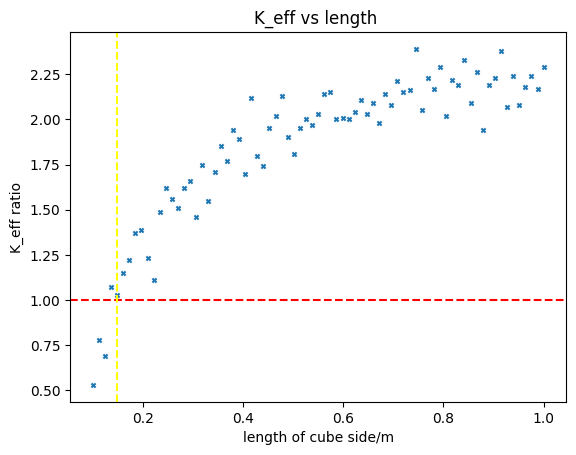

In [ ]:
plt.scatter(Ls,r,s = 9,marker='x')
plt.axhline(1, color = 'red', linestyle = '--')
plt.axvline(0.1475, color = 'yellow', linestyle = '--')
plt.xlabel('length of cube side/m')
plt.ylabel('K_eff ratio')
plt.title('K_eff vs length ')
plt.show()